# Лабораторная работа 4: Классификация брендов автомобилей


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import timm

from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Настройка device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

/Users/nikolai.khrustalev/Documents/ITMO/6-semester/CV/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
PyTorch version: 2.8.0


In [3]:
# Путь к данным
DATA_PATH = './confirmed_fronts'

In [ ]:
class CarBrandDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_samples_per_class=500):
        self.root_dir = root_dir
        self.transform = transform
        
        data = []
        print('Scanning dataset...')
        for brand in tqdm(os.listdir(root_dir)):
            brand_path = os.path.join(root_dir, brand)
            if not os.path.isdir(brand_path) or brand.startswith('.'):
                continue
            
            for year in os.listdir(brand_path):
                year_path = os.path.join(brand_path, year)
                if not os.path.isdir(year_path):
                    continue
                
                for filename in os.listdir(year_path):
                    if not filename.endswith('.jpg'):
                        continue

                    img_path = os.path.join(year_path, filename)
                    data.append({'path': img_path, 'brand': brand})
        
        self.df = pd.DataFrame(data)
        
        if max_samples_per_class:
            self.df = self.df.groupby('brand').head(max_samples_per_class).reset_index(drop=True)
        
        self.label_encoder = LabelEncoder()
        self.df['label'] = self.label_encoder.fit_transform(self.df['brand'])
        self.num_classes = len(self.label_encoder.classes_)
        
        print(f'Loaded {len(self.df)} samples')
        print(f'Number of classes (brands): {self.num_classes}')
        print(f'Brands: {self.label_encoder.classes_}')
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
dataset = CarBrandDataset(DATA_PATH, transform=train_transform)

Scanning dataset...


100%|██████████| 64/64 [00:00<00:00, 273.80it/s]

Loaded 15974 samples
Number of classes (brands): 63
Brands: ['Abarth' 'Alfa Romeo' 'Aston Martin' 'Audi' 'BMW' 'Bentley' 'Bugatti'
 'Cadillac' 'Chevrolet' 'Chrysler' 'Citroen' 'Corvette' 'DS' 'Dacia'
 'Daewoo' 'Daihatsu' 'Dodge' 'Ferrari' 'Fiat' 'Ford' 'Great Wall' 'Honda'
 'Hyundai' 'Infiniti' 'Isuzu' 'Jaguar' 'Jeep' 'Kia' 'Lamborghini'
 'Land Rover' 'Lexus' 'Lotus' 'MEV' 'MG' 'MINI' 'Maserati' 'Mazda'
 'McLaren' 'Mercedes-Benz' 'Mitsubishi' 'Nissan' 'Noble' 'Opel' 'Perodua'
 'Peugeot' 'Porsche' 'Proton' 'Renault' 'Rolls-Royce' 'Rover' 'SEAT'
 'SKODA' 'Saab' 'Smart' 'Ssangyong' 'Subaru' 'Suzuki' 'Tesla' 'Toyota'
 'Vauxhall' 'Volkswagen' 'Volvo' 'Zenos']


In [9]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

batch_size = 16 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Train: 11181, Val: 2396, Test: 2397


## 2. Модели для классификации

In [ ]:
class CarBrandClassifier(nn.Module):
    
    def __init__(self, model_name='resnet18', num_classes=10, pretrained=True):
        super(CarBrandClassifier, self).__init__()
        
        if model_name == 'resnet18':
            self.model = models.resnet18(pretrained=pretrained)
            in_features = self.model.fc.in_features
            self.model.fc = nn.Linear(in_features, num_classes)
        elif model_name == 'mobilenet_v2':
            self.model = models.mobilenet_v2(pretrained=pretrained)
            in_features = self.model.classifier[1].in_features
            self.model.classifier[1] = nn.Linear(in_features, num_classes)
            
        else:
            raise ValueError(f'Unknown model: {model_name}')
    
    def forward(self, x):
        return self.model(x)
    
    def freeze_backbone(self):
        for name, param in self.named_parameters():
            if 'fc' not in name and 'classifier' not in name:
                param.requires_grad = False
    
    def unfreeze_backbone(self):
        for param in self.parameters():
            param.requires_grad = True

## 3. Функции для обучения и оценки

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': loss.item(), 'acc': correct/total})
    
    return running_loss / len(loader), 100. * correct / total

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds, normalize=True)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    
    return {
        'loss': running_loss / len(loader),
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'predictions': all_preds,
        'labels': all_labels
    }

In [25]:
def train_model(model, train_loader, val_loader, device, num_epochs=10, lr=0.001, model_name='model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
    
    best_f1 = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1_macro': []}
    
    print(f'Starting training {model_name}...')
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        val_metrics = evaluate(model, val_loader, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1_macro'].append(val_metrics['f1_macro'])
        
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {np.mean(history["train_acc"]):.2f}%')
        print(f'Val Loss: {val_metrics["loss"]:.4f}, Val Acc: {val_metrics["accuracy"]*100:.2f}%, Val F1_macro: {val_metrics["f1_macro"]:.4f}')
        
        if val_metrics['f1_macro'] > best_f1:
            best_f1 = val_metrics['f1_macro']
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f'Model saved with F1_macro: {best_f1:.4f}')
        
        scheduler.step(val_metrics['f1_macro'])
    
    return history, best_f1

## 4. Эксперимент 1: ResNet-18 предобученный на ImageNet

In [ ]:
num_classes = dataset.num_classes
print(f'Number of classes: {num_classes}')

Number of classes: 63


In [ ]:
model_resnet18 = CarBrandClassifier(model_name='resnet18', num_classes=num_classes, pretrained=True)
model_resnet18.freeze_backbone()
model_resnet18 = model_resnet18.to(device)

/Users/nikolai.khrustalev/Documents/ITMO/6-semester/CV/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/nikolai.khrustalev/Documents/ITMO/6-semester/CV/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/nikolai.khrustalev/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 11.1MB/s]


In [ ]:
history_resnet18, best_f1_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, device,
    num_epochs=5, lr=0.001, model_name='resnet18_imagenet'
)

Starting training resnet18_imagenet...

Epoch 1/5


Evaluating: 100%|██████████| 150/150 [00:50<00:00,  3.00it/s]


Train Loss: 1.5838, Train Acc: 63.80%
Val Loss: 1.1748, Val Acc: 70.95%, Val F1_macro: 0.5280
Model saved with F1_macro: 0.5280

Epoch 2/5


Evaluating: 100%|██████████| 150/150 [00:50<00:00,  2.96it/s]


Train Loss: 1.0563, Train Acc: 68.94%
Val Loss: 0.9512, Val Acc: 75.46%, Val F1_macro: 0.6109
Model saved with F1_macro: 0.6109

Epoch 3/5


...

Train Loss: 0.8725, Train Acc: 72.02%
Val Loss: 0.8509, Val Acc: 78.05%, Val F1_macro: 0.6626
Model saved with F1_macro: 0.6626

Epoch 4/5


Evaluating: 100%|██████████| 150/150 [00:50<00:00,  2.96it/s]


Train Loss: 0.7710, Train Acc: 74.01%
Val Loss: 0.8411, Val Acc: 76.79%, Val F1_macro: 0.6701
Model saved with F1_macro: 0.6701

Epoch 5/5


Evaluating: 100%|██████████| 150/150 [00:51<00:00,  2.91it/s]

Train Loss: 0.6904, Train Acc: 75.60%
Val Loss: 0.7630, Val Acc: 79.76%, Val F1_macro: 0.6873
Model saved with F1_macro: 0.6873


## 5. Эксперимент 2: MobileNet-V2 (альтернативное предобучение)

In [ ]:
model_mobilenet = CarBrandClassifier(model_name='mobilenet_v2', num_classes=num_classes, pretrained=True)
model_mobilenet.freeze_backbone()
model_mobilenet = model_mobilenet.to(device)

/Users/nikolai.khrustalev/Documents/ITMO/6-semester/CV/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/nikolai.khrustalev/Documents/ITMO/6-semester/CV/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /Users/nikolai.khrustalev/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:04<00:00, 2.85MB/s]


In [ ]:
history_mobilenet, best_f1_mobilenet = train_model(
    model_mobilenet, train_loader, val_loader, device,
    num_epochs=5, lr=0.001, model_name='mobilenet_v2'
)

Starting training mobilenet_v2...

Epoch 1/5


Evaluating: 100%|██████████| 150/150 [01:17<00:00,  1.94it/s]


Train Loss: 1.9710, Train Acc: 53.55%
Val Loss: 1.1260, Val Acc: 72.33%, Val F1_macro: 0.5695
Model saved with F1_macro: 0.5695

Epoch 2/5


Evaluating: 100%|██████████| 150/150 [01:16<00:00,  1.96it/s]


Train Loss: 1.0859, Train Acc: 62.93%
Val Loss: 0.8960, Val Acc: 76.59%, Val F1_macro: 0.6436
Model saved with F1_macro: 0.6436

Epoch 3/5


...

Train Loss: 0.8869, Train Acc: 67.36%
Val Loss: 0.8553, Val Acc: 77.96%, Val F1_macro: 0.6839
Model saved with F1_macro: 0.6839

Epoch 4/5


Evaluating: 100%|██████████| 150/150 [01:16<00:00,  1.95it/s]


Train Loss: 0.7920, Train Acc: 70.04%
Val Loss: 0.7803, Val Acc: 78.55%, Val F1_macro: 0.6886
Model saved with F1_macro: 0.6886

Epoch 5/5


Evaluating: 100%|██████████| 150/150 [01:16<00:00,  1.97it/s]

Train Loss: 0.7322, Train Acc: 71.92%
Val Loss: 0.7346, Val Acc: 80.68%, Val F1_macro: 0.7277
Model saved with F1_macro: 0.7277


## 7. Оценка и сравнение моделей

In [ ]:
def load_and_evaluate(model_class, model_path, test_loader, device, **kwargs):
    """Загружает модель и оценивает на тесте"""
    if isinstance(model_class, str):
        if model_class == 'resnet18':
            model = CarBrandClassifier(model_name='resnet18', **kwargs)
        elif model_class == 'mobilenet':
            model = CarBrandClassifier(model_name='mobilenet_v2', **kwargs)
    else:
        model = model_class(**kwargs)
    
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)
    return evaluate(model, test_loader, device)

In [ ]:
print('='*60)
print('TEST SET EVALUATION')
print('='*60)

results = {}

# ResNet-18 ImageNet
try:
    results['ResNet-18 (ImageNet)'] = load_and_evaluate(
        'resnet18', 'best_resnet18_imagenet.pth', test_loader, device,
        num_classes=num_classes, pretrained=False
    )
    print(f"\nResNet-18 (ImageNet):")
    print(f"  Accuracy: {results['ResNet-18 (ImageNet)']['accuracy']*100:.2f}%")
    print(f"  F1 Macro: {results['ResNet-18 (ImageNet)']['f1_macro']:.4f}")
    print(f"  F1 Weighted: {results['ResNet-18 (ImageNet)']['f1_weighted']:.4f}")
except Exception as e:
    print(f'Could not evaluate ResNet-18: {e}')

# MobileNet-V2
try:
    results['MobileNet-V2'] = load_and_evaluate(
        'mobilenet', 'best_mobilenet_v2.pth', test_loader, device,
        num_classes=num_classes, pretrained=False
    )
    print(f"\nMobileNet-V2:")
    print(f"  Accuracy: {results['MobileNet-V2']['accuracy']*100:.2f}%")
    print(f"  F1 Macro: {results['MobileNet-V2']['f1_macro']:.4f}")
    print(f"  F1 Weighted: {results['MobileNet-V2']['f1_weighted']:.4f}")
except Exception as e:
    print(f'Could not evaluate MobileNet: {e}')

/Users/nikolai.khrustalev/Documents/ITMO/6-semester/CV/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/nikolai.khrustalev/Documents/ITMO/6-semester/CV/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


TEST SET EVALUATION


Evaluating: 100%|██████████| 150/150 [00:49<00:00,  3.04it/s]
/Users/nikolai.khrustalev/Documents/ITMO/6-semester/CV/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/nikolai.khrustalev/Documents/ITMO/6-semester/CV/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



ResNet-18 (ImageNet):
  Accuracy: 80.27%
  F1 Macro: 0.6633
  F1 Weighted: 0.7984


Evaluating: 100%|██████████| 150/150 [01:15<00:00,  1.98it/s]


MobileNet-V2:
  Accuracy: 81.06%
  F1 Macro: 0.7226
  F1 Weighted: 0.8088


In [ ]:
print('\n\n' + '='*60)
print('SUMMARY TABLE')
print('='*60)

summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [f"{r['accuracy']*100:.2f}%" for r in results.values()],
    'F1 Macro': [f"{r['f1_macro']:.4f}" for r in results.values()],
    'F1 Weighted': [f"{r['f1_weighted']:.4f}" for r in results.values()]
})

print(summary_df.to_string(index=False))



SUMMARY TABLE
               Model Accuracy F1 Macro F1 Weighted
ResNet-18 (ImageNet)   80.27%   0.6633      0.7984
        MobileNet-V2   81.06%   0.7226      0.8088


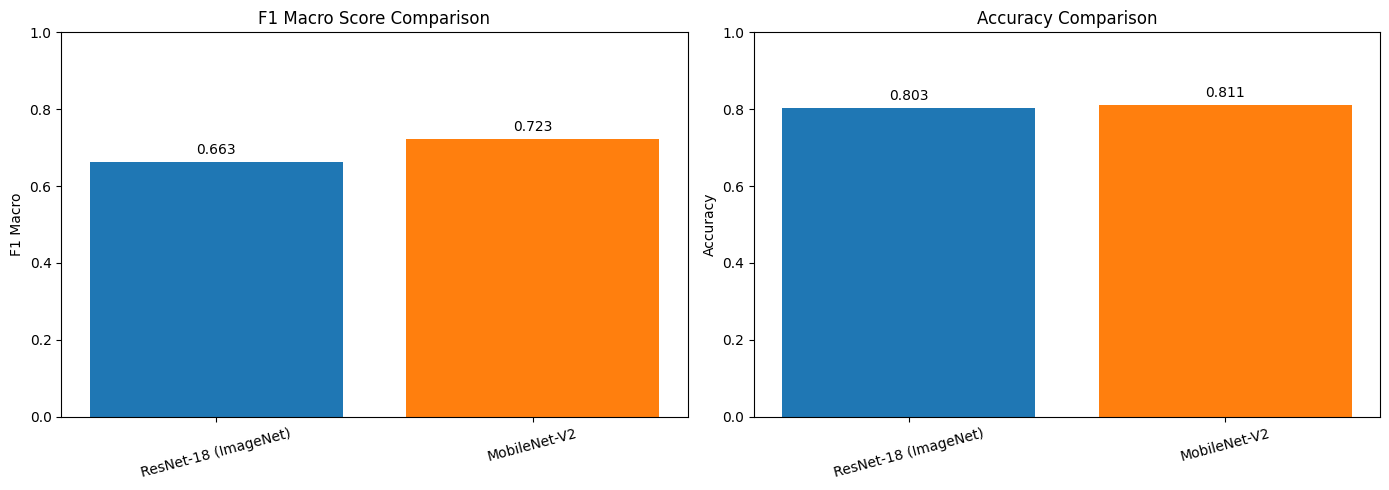

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(results.keys())
f1_macros = [results[m]['f1_macro'] for m in models]
accuracies = [results[m]['accuracy'] for m in models]

# F1 Macro
axes[0].bar(models, f1_macros, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('F1 Macro Score Comparison')
axes[0].set_ylabel('F1 Macro')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(f1_macros):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Accuracy
axes[1].bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Accuracy Comparison')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(accuracies):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()